Selected machines -> Healthy: 37 (anomalies=5), Abnormal: 25 (anomalies=27)


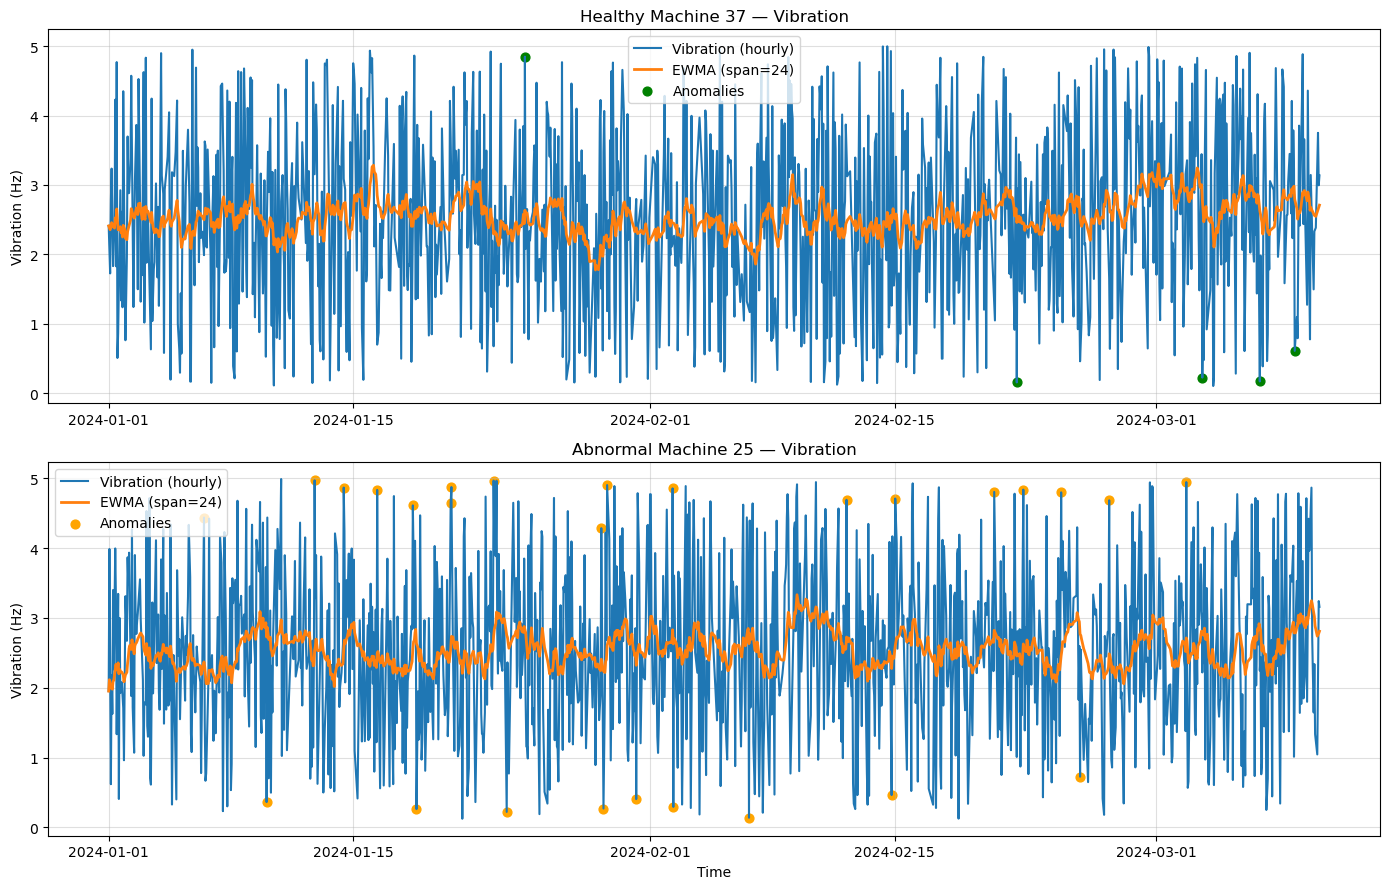

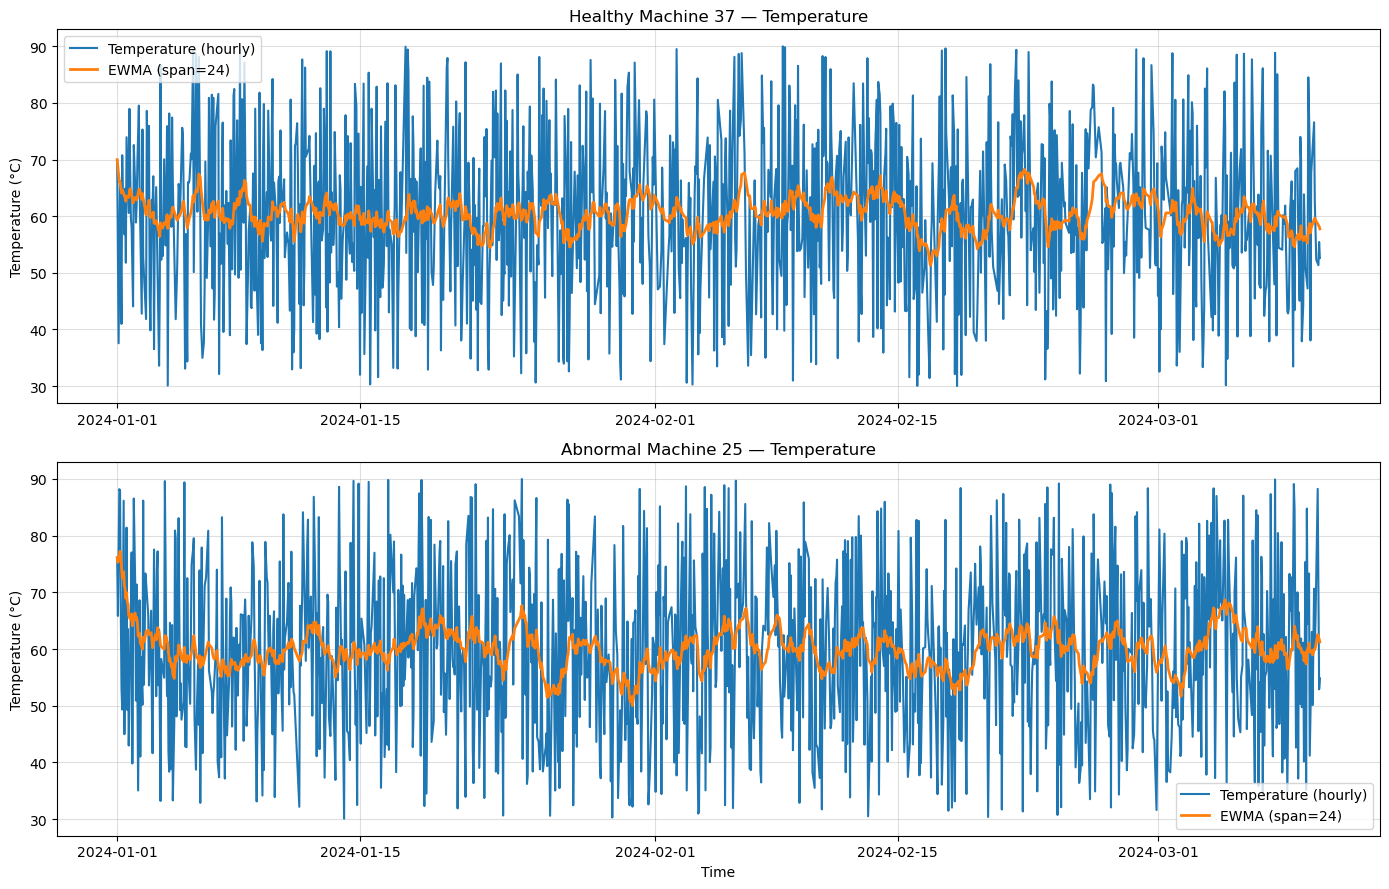


Correlation (Healthy Machine 37):
                Vibration_Hz  Temperature_C
Vibration_Hz          1.000          0.015
Temperature_C         0.015          1.000

Correlation (Abnormal Machine 25):
                Vibration_Hz  Temperature_C
Vibration_Hz          1.000         -0.012
Temperature_C        -0.012          1.000


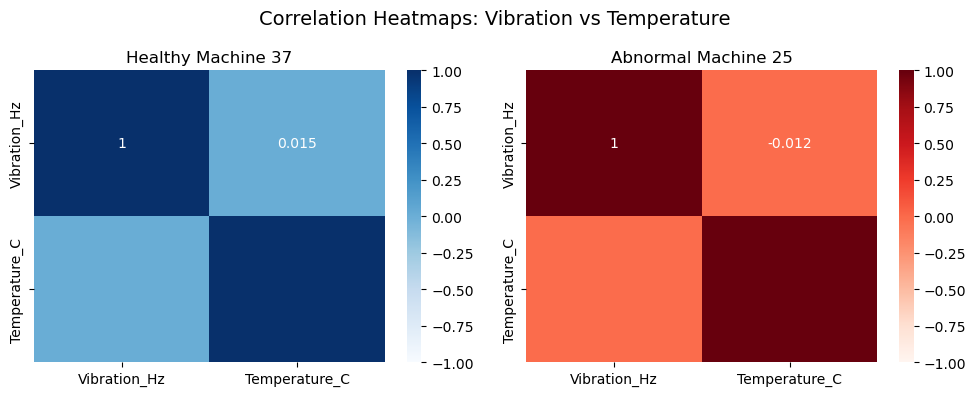

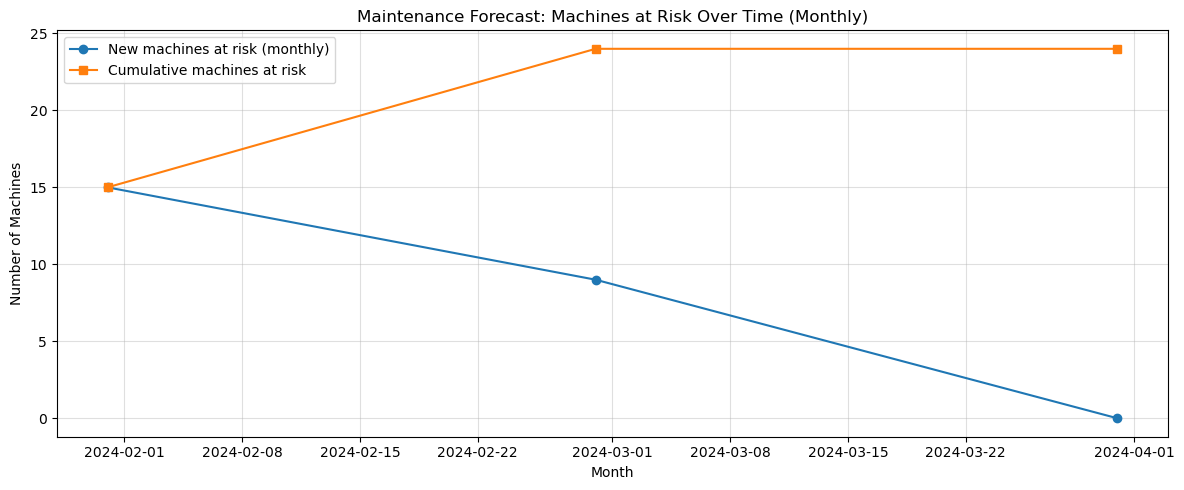


Monthly counts of machines newly at risk (first 12 rows):
Timestamp
2024-01-31    15
2024-02-29     9
2024-03-31     0
Freq: M

--- Final summaries ---
Healthy Machine 37: mean vibration=2.548, anomalies=5, mean temp=60.283
Abnormal Machine 25: mean vibration=2.551, anomalies=27, mean temp=59.849

Sample anomaly timestamps for Healthy Machine 37:
DatetimeIndex(['2024-01-24 20:00:00', '2024-02-22 00:00:00',
               '2024-03-03 15:00:00', '2024-03-06 22:00:00',
               '2024-03-08 22:00:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)

Sample anomaly timestamps for Abnormal Machine 25:
DatetimeIndex(['2024-01-06 11:00:00', '2024-01-10 01:00:00',
               '2024-01-12 19:00:00', '2024-01-14 11:00:00',
               '2024-01-16 09:00:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)

Analysis complete.


In [1]:
# ===============================================
# Full Analysis: Healthy vs Abnormal Machines
# with Vibration, Temperature, Correlation Heatmap,
# and Maintenance Forecast
# ===============================================

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# CONFIG - update file_path if needed
# ---------------------------
file_path = r"C:\Users\RIYA\Downloads\manufacturing_6G_dataset.csv"
resample_rule = 'H'   # hourly resampling
ewma_span = 24        # span for EWMA smoothing (24 hours)
anomaly_z_thresh = 2.0  # z-score threshold for marking vibration anomalies
maintenance_anomaly_threshold = 10  # anomalies in a month to mark "at risk"
maintenance_resample = 'M'  # 'M' = monthly aggregation

# ---------------------------
# Step 0: Load & verify dataset
# ---------------------------
if not os.path.exists(file_path):
    raise FileNotFoundError(f"CSV not found at {file_path}. Update file_path if needed.")

df = pd.read_csv(file_path)

# verify required columns
required_cols = {'Timestamp', 'Machine_ID', 'Vibration_Hz', 'Temperature_C'}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {missing}")

# convert timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

# ---------------------------
# Helper: process a single machine
# ---------------------------
def process_machine(df, machine_id, resample_rule='H', ewma_span=24, z_thresh=2.0):
    df_m = df[df['Machine_ID'] == machine_id].set_index('Timestamp').sort_index()
    vib = df_m['Vibration_Hz'].resample(resample_rule).mean().dropna()
    temp = df_m['Temperature_C'].resample(resample_rule).mean().dropna()
    vib_ewma = vib.ewm(span=ewma_span, adjust=False).mean()
    temp_ewma = temp.ewm(span=ewma_span, adjust=False).mean()
    roll_mean_v = vib.rolling(window=ewma_span, min_periods=max(1, ewma_span//2)).mean()
    roll_std_v = vib.rolling(window=ewma_span, min_periods=max(1, ewma_span//2)).std().replace(0, np.nan)
    z_v = (vib - roll_mean_v) / roll_std_v
    vib_anoms = vib[z_v.abs() > z_thresh]
    return vib, temp, vib_ewma, temp_ewma, vib_anoms, z_v

# ---------------------------
# Step 1: Compute anomaly counts & select machines
# ---------------------------
machine_ids = sorted(df['Machine_ID'].unique().tolist())
anomaly_counts = {}
for mid in machine_ids:
    try:
        vib, temp, vib_ewma, temp_ewma, anoms, z = process_machine(
            df, mid, resample_rule=resample_rule, ewma_span=ewma_span, z_thresh=anomaly_z_thresh)
        anomaly_counts[mid] = len(anoms)
    except Exception:
        anomaly_counts[mid] = np.nan

valid_counts = {k: v for k, v in anomaly_counts.items() if not pd.isna(v)}
if not valid_counts:
    raise ValueError("No machines with usable data.")

healthy_id = min(valid_counts, key=valid_counts.get)
abnormal_id = max(valid_counts, key=valid_counts.get)
print(f"Selected machines -> Healthy: {healthy_id} (anomalies={valid_counts[healthy_id]}), "
      f"Abnormal: {abnormal_id} (anomalies={valid_counts[abnormal_id]})")

# ---------------------------
# Step 2: Process selected machines
# ---------------------------
vib_h, temp_h, vib_ewma_h, temp_ewma_h, anoms_h, z_h = process_machine(df, healthy_id,
                                                                       resample_rule, ewma_span, anomaly_z_thresh)
vib_a, temp_a, vib_ewma_a, temp_ewma_a, anoms_a, z_a = process_machine(df, abnormal_id,
                                                                       resample_rule, ewma_span, anomaly_z_thresh)

# ---------------------------
# Step 3: Plot comparison - Vibration
# ---------------------------
plt.figure(figsize=(14,9), dpi=100)

plt.subplot(2,1,1)
plt.plot(vib_h.index, vib_h.values, label='Vibration (hourly)')
plt.plot(vib_ewma_h.index, vib_ewma_h.values, label=f'EWMA (span={ewma_span})', linewidth=2)
if not anoms_h.empty:
    plt.scatter(anoms_h.index, anoms_h.values, color='green', s=40, label='Anomalies')
plt.title(f"Healthy Machine {healthy_id} — Vibration")
plt.ylabel("Vibration (Hz)")
plt.legend(); plt.grid(alpha=0.4)

plt.subplot(2,1,2)
plt.plot(vib_a.index, vib_a.values, label='Vibration (hourly)')
plt.plot(vib_ewma_a.index, vib_ewma_a.values, label=f'EWMA (span={ewma_span})', linewidth=2)
if not anoms_a.empty:
    plt.scatter(anoms_a.index, anoms_a.values, color='orange', s=40, label='Anomalies')
plt.title(f"Abnormal Machine {abnormal_id} — Vibration")
plt.ylabel("Vibration (Hz)")
plt.xlabel("Time")
plt.legend(); plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

# ---------------------------
# Step 4: Plot comparison - Temperature
# ---------------------------
plt.figure(figsize=(14,9), dpi=100)

plt.subplot(2,1,1)
plt.plot(temp_h.index, temp_h.values, label='Temperature (hourly)')
plt.plot(temp_ewma_h.index, temp_ewma_h.values, label=f'EWMA (span={ewma_span})', linewidth=2)
plt.title(f"Healthy Machine {healthy_id} — Temperature")
plt.ylabel("Temperature (°C)")
plt.legend(); plt.grid(alpha=0.4)

plt.subplot(2,1,2)
plt.plot(temp_a.index, temp_a.values, label='Temperature (hourly)')
plt.plot(temp_ewma_a.index, temp_ewma_a.values, label=f'EWMA (span={ewma_span})', linewidth=2)
plt.title(f"Abnormal Machine {abnormal_id} — Temperature")
plt.ylabel("Temperature (°C)")
plt.xlabel("Time")
plt.legend(); plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

# ---------------------------
# Step 5: Correlation Heatmaps
# ---------------------------
merged_h = pd.concat([vib_h, temp_h], axis=1).dropna()
merged_h.columns = ['Vibration_Hz', 'Temperature_C']
corr_h = merged_h.corr().round(3)

merged_a = pd.concat([vib_a, temp_a], axis=1).dropna()
merged_a.columns = ['Vibration_Hz', 'Temperature_C']
corr_a = merged_a.corr().round(3)

print(f"\nCorrelation (Healthy Machine {healthy_id}):\n", corr_h)
print(f"\nCorrelation (Abnormal Machine {abnormal_id}):\n", corr_a)

fig, axes = plt.subplots(1, 2, figsize=(10,4), dpi=100)
sns.heatmap(corr_h, annot=True, cmap="Blues", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title(f"Healthy Machine {healthy_id}")
sns.heatmap(corr_a, annot=True, cmap="Reds", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title(f"Abnormal Machine {abnormal_id}")
plt.suptitle("Correlation Heatmaps: Vibration vs Temperature", fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------
# Step 6: Maintenance Forecast
# ---------------------------
def anomaly_flags_series(df, machine_id, resample_rule='H', ewma_span=24, z_thresh=2.0):
    df_m = df[df['Machine_ID'] == machine_id].set_index('Timestamp').sort_index()
    vib = df_m['Vibration_Hz'].resample(resample_rule).mean().dropna()
    roll_mean = vib.rolling(window=ewma_span, min_periods=max(1, ewma_span//2)).mean()
    roll_std = vib.rolling(window=ewma_span, min_periods=max(1, ewma_span//2)).std().replace(0, np.nan)
    z = (vib - roll_mean) / roll_std
    return (z.abs() > z_thresh).astype(int)

monthly_flags_list = []
for mid in machine_ids:
    flags = anomaly_flags_series(df, mid, resample_rule, ewma_span, anomaly_z_thresh)
    if flags.empty: continue
    monthly_counts = flags.resample(maintenance_resample).sum()
    monthly_at_risk = (monthly_counts >= maintenance_anomaly_threshold).astype(int).rename(mid)
    monthly_flags_list.append(monthly_at_risk)

replacement_df = pd.concat(monthly_flags_list, axis=1).fillna(0).astype(int)
machines_at_risk_monthly = replacement_df.sum(axis=1)
machines_cumulative = machines_at_risk_monthly.cumsum()

plt.figure(figsize=(12,5), dpi=100)
plt.plot(machines_at_risk_monthly.index, machines_at_risk_monthly.values, marker='o', label='New machines at risk (monthly)')
plt.plot(machines_cumulative.index, machines_cumulative.values, marker='s', label='Cumulative machines at risk')
plt.title("Maintenance Forecast: Machines at Risk Over Time (Monthly)")
plt.xlabel("Month"); plt.ylabel("Number of Machines")
plt.legend(); plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

print("\nMonthly counts of machines newly at risk (first 12 rows):")
print(machines_at_risk_monthly.head(12).to_string())

# ---------------------------
# Step 7: Final summaries
# ---------------------------
print("\n--- Final summaries ---")
print(f"Healthy Machine {healthy_id}: mean vibration={vib_h.mean():.3f}, anomalies={len(anoms_h)}, mean temp={temp_h.mean():.3f}")
print(f"Abnormal Machine {abnormal_id}: mean vibration={vib_a.mean():.3f}, anomalies={len(anoms_a)}, mean temp={temp_a.mean():.3f}")

if not anoms_h.empty:
    print(f"\nSample anomaly timestamps for Healthy Machine {healthy_id}:")
    print(anoms_h.index[:5])
if not anoms_a.empty:
    print(f"\nSample anomaly timestamps for Abnormal Machine {abnormal_id}:")
    print(anoms_a.index[:5])

print("\nAnalysis complete.")
